# Credit Risk Scorecard and Expected Loss Model

**Application-scored probability of default for consumer loans, delivered as an interpretable scorecard, benchmarked against a gradient boosting challenger, and translated into expected loss and a lending decision.**

## Overview

This project builds a credit risk model for consumer loan applications on LendingClub's public loan book. The goal is not to maximise a classification score but to produce something a lending function could actually use: an estimate of each applicant's probability of default at the moment of decision, expressed as a transparent, points-based scorecard, and turned into an expected loss, a price that reflects each borrower's risk, and a lending decision.

A gradient boosting model is trained alongside the scorecard as a challenger, to measure how much predictive accuracy is given up by keeping the deployed model interpretable. The work closes with a SHAP explanation of the challenger, a pricing step that is validated against the lender's own interest rates, a fairness review, and a model-risk summary written in the style of a validation document.

## Method and scope

Three decisions define the modelling and are worth stating up front, because they are what separate a credit model from a generic classifier.

**Every feature is known at application time.** Fields that are populated only after a loan resolves, such as recoveries, payments, or remaining principal, are never loaded. Loading only a whitelist of application-time columns removes the most common source of target leakage in this dataset before any modelling begins.

**LendingClub's own grade, sub-grade, interest rate, and installment are excluded.** These encode the lender's existing risk decision. Excluding them means the model reflects an independent view of borrower risk rather than relearning a decision that has already been made.

**Realistic expectations.** With leakage removed and the lender's own assessment excluded, an honest application-only default model on this data typically ranks in the high 0.60s to low 0.70s on AUC. That is a genuine credit result. The value here is method and interpretability, not a headline number.

## Pipeline

1. Data loading and target definition
2. Cleaning and feature preparation
3. Time-based train and test split
4. Exploratory analysis
5. Weight of evidence transformation and information value screening
6. Credit scorecard (logistic regression, scaled to points)
7. Gradient boosting challenger with probability calibration
8. Evaluation and honest comparison
9. Interpretability with SHAP
10. Probability of default to expected loss and a baseline lending cutoff
11. Pricing the risk and validating it against the lender's own rates
12. Fairness and adverse-impact review
13. Model-risk summary and limitations

*Requirements: pandas, numpy, matplotlib, seaborn, scikit-learn, xgboost, shap. Set the data path in the configuration cell and run top to bottom.*

In [1]:
# --- Dependency bootstrap -------------------------------------------------
# Ensures xgboost and shap are installed in the SAME Python that is running
# this notebook (sys.executable), regardless of which interpreter/kernel is
# selected. Run this cell first. Safe to re-run: it only installs if missing.
import sys, subprocess, importlib

print("Kernel Python:", sys.executable)

for pkg in ("xgboost", "shap"):
    try:
        importlib.import_module(pkg)
    except ImportError:
        print(f"Installing {pkg} into this kernel ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

import xgboost, shap
print("xgboost", xgboost.__version__, "| shap", shap.__version__)

Kernel Python: /opt/anaconda3/bin/python
xgboost 3.3.0 | shap 0.52.0


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss, confusion_matrix

SEED = 42
np.random.seed(SEED)
pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

## 1. Data loading and target definition

Leakage is handled at load time. Rather than reading the full file and dropping unsafe columns afterwards, the loader reads only a whitelist of application-time fields plus the outcome column. Post-outcome fields never enter the frame, so they cannot leak by accident.

The target is defined from resolved outcomes only. A loan that was fully paid is a good (0); a loan that was charged off or defaulted is a bad (1). Loans still in repayment have no known outcome and are dropped, which keeps the label clean.

In [3]:
# --- configuration: LendingClub data files ---
# "Accepted" loans file: the main dataset used by the whole pipeline.
ACCEPTED_DATA_PATH = os.environ.get(
    "LENDINGCLUB_ACCEPTED",
    "/Users/jj/Desktop/FOLDER/Resume/Resume Project/Banking/archive/accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv",
)

# "Rejected" applications file (not used by the main pipeline; kept here for reference).
REJECTED_DATA_PATH = os.environ.get(
    "LENDINGCLUB_REJECTED",
    "/Users/jj/Desktop/FOLDER/Resume/Resume Project/Banking/archive/rejected_2007_to_2018q4.csv/rejected_2007_to_2018Q4.csv",
)

# Application-time borrower attributes: information available at the moment of decision.
CORE_FEATURES = [
    "loan_amnt", "term", "emp_length", "home_ownership", "annual_inc",
    "verification_status", "purpose", "dti", "delinq_2yrs", "earliest_cr_line",
    "fico_range_low", "fico_range_high", "inq_last_6mths", "open_acc", "pub_rec",
    "revol_bal", "revol_util", "total_acc", "mort_acc", "pub_rec_bankruptcies",
    "application_type", "addr_state",
]
# Kept only for the time-based split and credit-history derivation, not used as a feature.
HELPER_COLS = ["issue_d"]
# LendingClub's own risk grade and pricing, excluded so the model is independent of it.
LC_ASSESSMENT = ["grade", "sub_grade", "int_rate", "installment"]

TARGET = "loan_status"
PAID = {"Fully Paid"}
DEFAULTED = {"Charged Off", "Default"}


def load_application_data(path, include_lc_assessment=False):
    """Read only application-time columns plus the outcome, so leakage cannot enter."""
    requested = CORE_FEATURES + HELPER_COLS + [TARGET]
    if include_lc_assessment:
        requested += LC_ASSESSMENT
    available = pd.read_csv(path, nrows=0).columns.tolist()
    use = [c for c in requested if c in available]
    missing = [c for c in requested if c not in available]
    if missing:
        print("Columns not found in this file, skipped:", missing)
    return pd.read_csv(path, usecols=use, low_memory=False)


raw = load_application_data(ACCEPTED_DATA_PATH)
print(f"Loaded {len(raw):,} rows and {raw.shape[1]} columns.")

Loaded 2,260,701 rows and 24 columns.


In [4]:
def define_target(df):
    """Map resolved loan outcomes to a binary default flag and drop unresolved loans."""
    df = df.copy()
    status = df[TARGET].astype(str).str.strip()
    df["default"] = np.where(status.isin(DEFAULTED), 1,
                     np.where(status.isin(PAID), 0, np.nan))
    unresolved = int(df["default"].isna().sum())
    print(f"Dropping {unresolved:,} unresolved loans (current, late, grace, or policy-excluded).")
    df = df[df["default"].notna()].copy()
    df["default"] = df["default"].astype(int)
    return df.drop(columns=[TARGET])


df = define_target(raw)
print(f"Modelling set: {len(df):,} loans. Observed default rate: {df['default'].mean():.3f}")

Dropping 915,351 unresolved loans (current, late, grace, or policy-excluded).
Modelling set: 1,345,350 loans. Observed default rate: 0.200


## 2. Cleaning and feature preparation

Only row-wise transformations happen here, meaning transformations that use a single record and no cross-record statistics. Anything that has to be learned from the data, such as bin boundaries or category encodings, is deliberately deferred until after the train and test split so that no information from the test set influences the model.

In [5]:
EMP_LENGTH_MAP = {
    "< 1 year": 0, "1 year": 1, "2 years": 2, "3 years": 3, "4 years": 4,
    "5 years": 5, "6 years": 6, "7 years": 7, "8 years": 8, "9 years": 9,
    "10+ years": 10,
}


def parse_lc_date(s):
    """Parse LendingClub month-year strings robustly across formats."""
    dt = pd.to_datetime(s, format="%b-%Y", errors="coerce")
    if dt.isna().mean() > 0.5:
        dt = pd.to_datetime(s, errors="coerce")
    return dt


def clean_features(df):
    df = df.copy()
    df["term"] = df["term"].astype(str).str.extract(r"(\d+)").astype(float)
    df["revol_util"] = (df["revol_util"].astype(str)
                        .str.rstrip("%").replace({"nan": np.nan}).astype(float))
    df["emp_length"] = df["emp_length"].map(EMP_LENGTH_MAP)
    # Single FICO score from the reported range.
    df["fico"] = (df["fico_range_low"] + df["fico_range_high"]) / 2
    # Credit history length in months at origination.
    issue = parse_lc_date(df["issue_d"])
    earliest = parse_lc_date(df["earliest_cr_line"])
    df["credit_history_months"] = (issue.dt.year - earliest.dt.year) * 12 + \
                                  (issue.dt.month - earliest.dt.month)
    df["issue_d"] = issue  # keep parsed date for the time-based split
    return df.drop(columns=["fico_range_low", "fico_range_high", "earliest_cr_line"])


df = clean_features(df)
print(df[["term", "emp_length", "revol_util", "fico", "credit_history_months"]].describe().round(1))

            term  emp_length  revol_util       fico  credit_history_months
count  1345350.0   1266834.0   1344493.0  1345350.0              1345350.0
mean        41.8         6.0        51.8      698.2                  195.1
std         10.3         3.7        24.5       31.9                   90.1
min         36.0         0.0         0.0      627.0                   36.0
25%         36.0         2.0        33.4      672.0                  135.0
50%         36.0         6.0        52.2      692.0                  177.0
75%         36.0        10.0        70.7      712.0                  240.0
max         60.0        10.0       892.3      847.5                  999.0


## 3. Time-based train and test split

The split is by loan issue date, not random. The model trains on earlier loans and is tested on later ones, which mirrors how a scorecard is deployed: it is fit on history and applied to future applicants. A time-based split also avoids the mild leakage that a random split introduces when loans from the same period share economic conditions. The test set is held out and untouched until evaluation.

In [6]:
df = df.sort_values("issue_d")
split_date = df["issue_d"].quantile(0.80)
train = df[df["issue_d"] <= split_date].copy()
test = df[df["issue_d"] > split_date].copy()

print(f"Split date: {split_date.date()}")
print(f"Train: {len(train):,} loans, default rate {train['default'].mean():.3f}")
print(f"Test:  {len(test):,} loans, default rate {test['default'].mean():.3f}")

NUMERIC = ["loan_amnt", "annual_inc", "dti", "fico", "revol_util", "revol_bal",
           "delinq_2yrs", "inq_last_6mths", "open_acc", "pub_rec", "total_acc",
           "mort_acc", "pub_rec_bankruptcies", "term", "emp_length",
           "credit_history_months"]
CATEGORICAL = ["home_ownership", "verification_status", "purpose",
               "application_type", "addr_state"]
FEATURES = NUMERIC + CATEGORICAL

Split date: 2016-10-01
Train: 1,081,337 loans, default rate 0.195
Test:  264,013 loans, default rate 0.218


## 4. Exploratory analysis

Exploration is done on the training set only, so that nothing observed here leaks a view of the test data into modelling choices. The aim is to understand how each factor relates to default in a way that agrees with credit intuition.

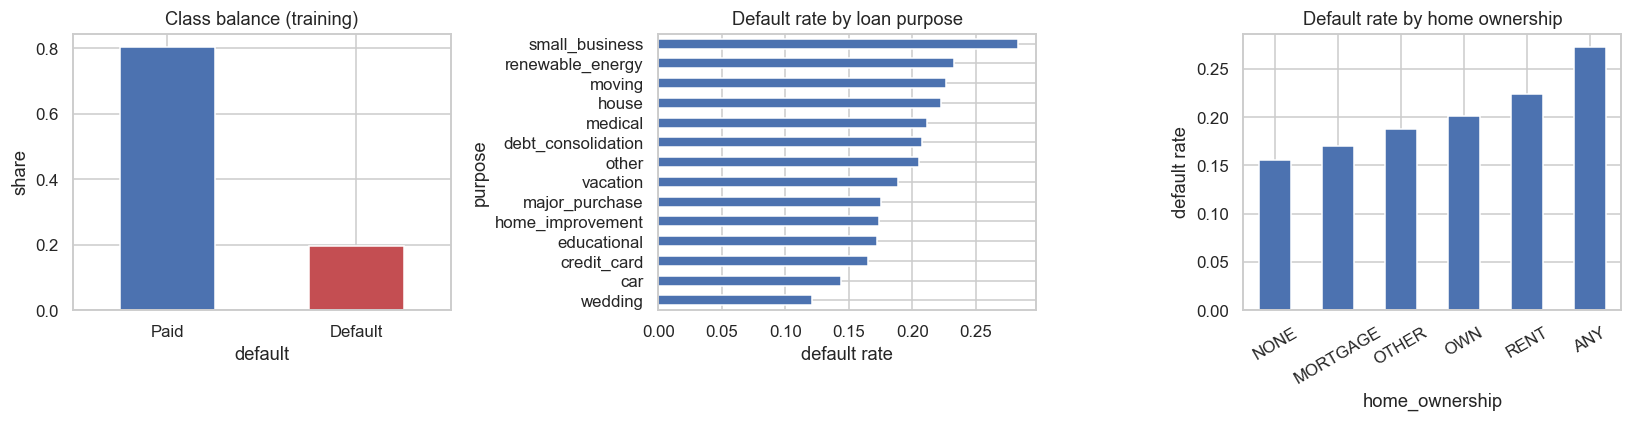

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

train["default"].value_counts(normalize=True).rename({0: "Paid", 1: "Default"}).plot(
    kind="bar", ax=axes[0], color=["#4c72b0", "#c44e52"])
axes[0].set_title("Class balance (training)")
axes[0].set_ylabel("share")
axes[0].tick_params(axis="x", rotation=0)

rate_by_purpose = train.groupby("purpose")["default"].mean().sort_values()
rate_by_purpose.plot(kind="barh", ax=axes[1], color="#4c72b0")
axes[1].set_title("Default rate by loan purpose")
axes[1].set_xlabel("default rate")

rate_by_home = train.groupby("home_ownership")["default"].mean().sort_values()
rate_by_home.plot(kind="bar", ax=axes[2], color="#4c72b0")
axes[2].set_title("Default rate by home ownership")
axes[2].set_ylabel("default rate")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout(); plt.show()

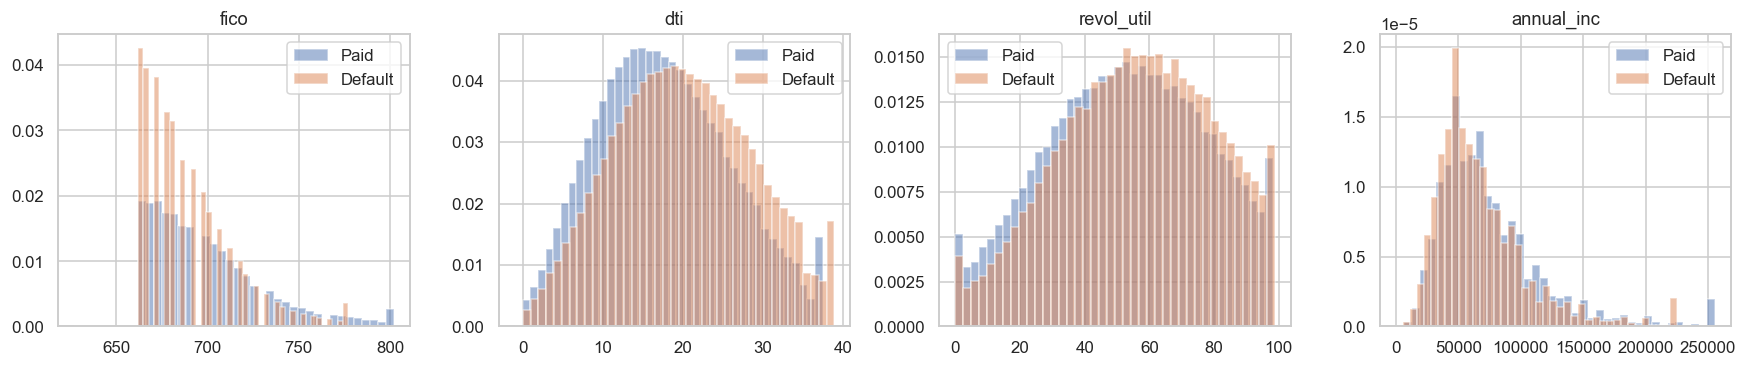

Missing rate by feature:
emp_length              0.054
mort_acc                0.044
pub_rec_bankruptcies    0.001
revol_util              0.001
dti                     0.000
inq_last_6mths          0.000


In [8]:
key_num = ["fico", "dti", "revol_util", "annual_inc"]
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, col in zip(axes, key_num):
    for label, sub in train.groupby("default"):
        vals = sub[col].clip(upper=sub[col].quantile(0.99))
        ax.hist(vals.dropna(), bins=40, alpha=0.5,
                label=("Default" if label == 1 else "Paid"), density=True)
    ax.set_title(col); ax.legend()
plt.tight_layout(); plt.show()

missing = train[FEATURES].isna().mean().sort_values(ascending=False)
missing = missing[missing > 0]
print("Missing rate by feature:")
print(missing.round(3).to_string() if len(missing) else "  none")

## 5. Weight of evidence and information value

Each feature is binned and recoded to its weight of evidence, the log ratio of the share of goods to the share of bads in the bin. This gives every feature the same scale and a monotonic, readable relationship with risk, and it is what makes the downstream logistic regression a true scorecard. Information value summarises each feature's separating power and is used to screen out weak predictors. Bins are learned on the training set and applied unchanged to the test set. Missing values are treated as their own bin rather than imputed, so the pattern of missingness is preserved.

In [9]:
def fit_woe(train, feature, target, n_bins=10):
    """Learn bins and weight-of-evidence values for one feature on the training set."""
    d = train[[feature, target]].copy()
    numeric = pd.api.types.is_numeric_dtype(d[feature])
    if numeric:
        edges = np.unique(np.nanquantile(d[feature].astype(float),
                                         np.linspace(0, 1, n_bins + 1)))
        edges = edges.astype(float)
        edges[0], edges[-1] = -np.inf, np.inf
        b = pd.cut(d[feature], bins=edges).astype(object)
        b[d[feature].isna()] = "Missing"
    else:
        edges = None
        b = d[feature].astype(object).where(d[feature].notna(), "Missing")
    d["bin"] = b
    grp = d.groupby("bin", observed=False)[target].agg(n="count", bad="sum")
    grp["good"] = grp["n"] - grp["bad"]
    k, tg, tb = len(grp), grp["good"].sum(), grp["bad"].sum()
    grp["dist_good"] = (grp["good"] + 0.5) / (tg + 0.5 * k)
    grp["dist_bad"] = (grp["bad"] + 0.5) / (tb + 0.5 * k)
    grp["woe"] = np.log(grp["dist_good"] / grp["dist_bad"])
    grp["iv"] = (grp["dist_good"] - grp["dist_bad"]) * grp["woe"]
    return {"feature": feature, "numeric": numeric, "edges": edges,
            "woe_map": grp["woe"].to_dict(), "table": grp, "iv": float(grp["iv"].sum())}


def apply_woe(df, spec):
    """Map a feature's values onto the weight-of-evidence learned on training."""
    f = spec["feature"]
    if spec["numeric"]:
        b = pd.cut(df[f], bins=spec["edges"]).astype(object)
        b[df[f].isna()] = "Missing"
    else:
        b = df[f].astype(object).where(df[f].notna(), "Missing")
    return b.map(spec["woe_map"]).fillna(0.0).astype(float)


woe_specs = {f: fit_woe(train, f, "default") for f in FEATURES}
iv_rank = pd.Series({f: woe_specs[f]["iv"] for f in FEATURES}).sort_values(ascending=False)
print("Information value by feature:")
print(iv_rank.round(3).to_string())

Information value by feature:
fico                     0.123
dti                      0.077
verification_status      0.053
mort_acc                 0.035
loan_amnt                0.032
annual_inc               0.031
home_ownership           0.026
purpose                  0.020
revol_util               0.019
inq_last_6mths           0.018
addr_state               0.015
credit_history_months    0.010
emp_length               0.009
open_acc                 0.008
revol_bal                0.004
delinq_2yrs              0.002
pub_rec                  0.001
pub_rec_bankruptcies     0.001
total_acc                0.001
application_type         0.000
term                     0.000


In [10]:
# Keep features with at least weak separating power; drop the rest.
selected = iv_rank[iv_rank >= 0.02].index.tolist()
print(f"Selected {len(selected)} of {len(FEATURES)} features (IV >= 0.02).")

X_train_woe = pd.DataFrame({f: apply_woe(train, woe_specs[f]) for f in selected},
                           index=train.index)
X_test_woe = pd.DataFrame({f: apply_woe(test, woe_specs[f]) for f in selected},
                          index=test.index)
y_train, y_test = train["default"], test["default"]

Selected 7 of 21 features (IV >= 0.02).


### Monotonicity check

Before the scorecard is trusted, each numeric feature's weight of evidence is plotted across its bins. A sensible credit feature is monotonic, meaning risk moves in one consistent direction as the feature increases. For example, default risk should fall steadily as the credit score rises. A numeric feature whose weight of evidence zig-zags usually reflects a noisy bin split rather than a real relationship, so it is flagged here. Categorical features carry no monotonicity expectation and are not tested.

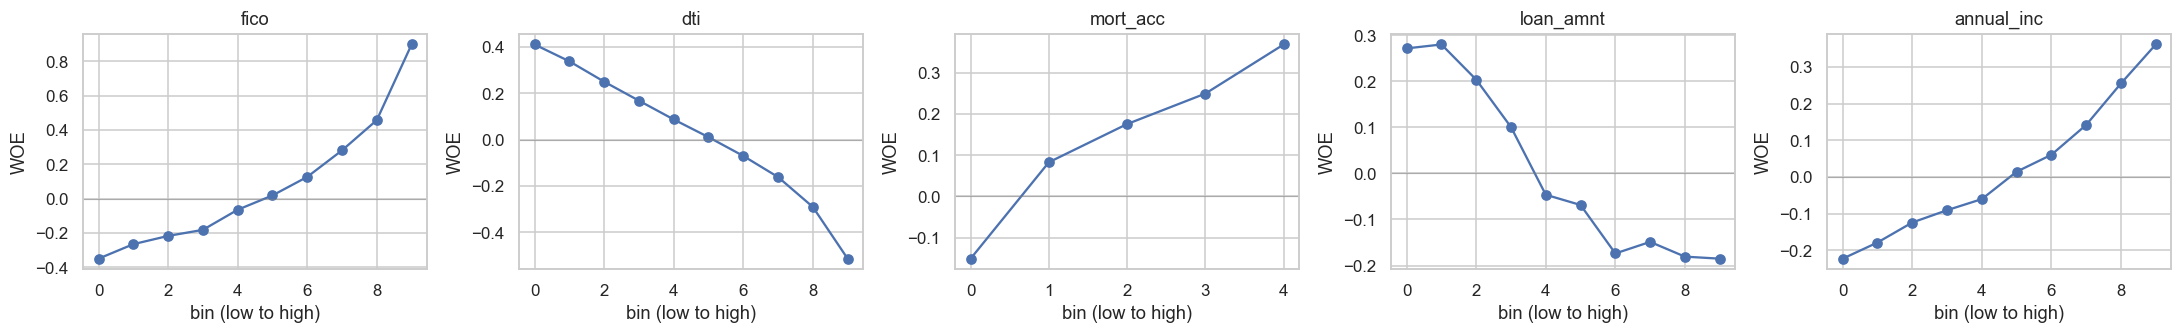

Monotonicity of numeric features:
  fico                     monotonic
  dti                      monotonic
  mort_acc                 monotonic
  loan_amnt                NON-monotonic
  annual_inc               monotonic


In [11]:
# Plot weight of evidence across bins for each selected numeric feature and flag
# any that are not monotonic. Bins are Interval objects, so the non-missing bins
# are ordered explicitly by their left edge; "Missing" is handled separately.
num_selected = [f for f in selected if f in NUMERIC]

fig, axes = plt.subplots(1, len(num_selected), figsize=(4 * len(num_selected), 3.2))
if len(num_selected) == 1:
    axes = [axes]

mono_flags = {}
for ax, f in zip(axes, num_selected):
    tab = woe_specs[f]["table"]
    core_bins = sorted([b for b in tab.index if b != "Missing"], key=lambda iv: iv.left)
    woe_core = tab.loc[core_bins, "woe"].values
    ax.plot(range(len(woe_core)), woe_core, "o-", color="#4c72b0")
    ax.axhline(0, color="grey", linewidth=0.8, alpha=0.5)
    ax.set_title(f)
    ax.set_xlabel("bin (low to high)")
    ax.set_ylabel("WOE")
    monotonic = np.all(np.diff(woe_core) >= 0) or np.all(np.diff(woe_core) <= 0)
    mono_flags[f] = "monotonic" if monotonic else "NON-monotonic"

plt.tight_layout(); plt.show()

print("Monotonicity of numeric features:")
for f, flag in mono_flags.items():
    print(f"  {f:<24} {flag}")


## 6. Credit scorecard

The scorecard is a logistic regression fit on the weight-of-evidence features. Because the inputs are monotonic and the model is linear, each feature's contribution is transparent. The fitted model is then scaled into points using the standard formulation: a chosen reference score, reference odds, and a points-to-double-the-odds setting. The result is a table a credit officer can read directly, where a higher score means a safer applicant, while carrying exactly the same information as the underlying regression.

In [12]:
scorecard_model = LogisticRegression(max_iter=1000)
scorecard_model.fit(X_train_woe, y_train)

coefs = dict(zip(selected, scorecard_model.coef_[0]))
intercept = scorecard_model.intercept_[0]

pd_train_sc = scorecard_model.predict_proba(X_train_woe)[:, 1]
pd_test_sc = scorecard_model.predict_proba(X_test_woe)[:, 1]
print(f"Scorecard AUC  train {roc_auc_score(y_train, pd_train_sc):.3f}"
      f"  test {roc_auc_score(y_test, pd_test_sc):.3f}")

Scorecard AUC  train 0.654  test 0.664


In [13]:
def build_scorecard(specs, coefs, intercept, features,
                    pdo=20, base_score=600, base_odds=50):
    """Scale the logistic regression into a points-based scorecard (higher = safer)."""
    factor = pdo / np.log(2)
    offset = base_score - factor * np.log(base_odds)
    n = len(features)
    rows = []
    for f in features:
        for bin_key, woe in specs[f]["woe_map"].items():
            points = -(woe * coefs[f] + intercept / n) * factor + offset / n
            rows.append({"feature": f, "bin": str(bin_key),
                         "woe": round(woe, 3), "points": int(round(points))})
    return pd.DataFrame(rows)


scorecard = build_scorecard(woe_specs, coefs, intercept, selected)
# Show the strongest feature's point allocation as an example.
top_feature = iv_rank.index[0]
print(f"Point allocation for '{top_feature}':")
print(scorecard[scorecard["feature"] == top_feature].to_string(index=False))

Point allocation for 'fico':
feature            bin    woe  points
   fico  (-inf, 667.0] -0.350      66
   fico (667.0, 672.0] -0.266      68
   fico (672.0, 677.0] -0.218      70
   fico (677.0, 682.0] -0.182      71
   fico (682.0, 692.0] -0.065      74
   fico (692.0, 697.0]  0.018      76
   fico (697.0, 707.0]  0.126      79
   fico (707.0, 717.0]  0.281      83
   fico (717.0, 737.0]  0.457      88
   fico   (737.0, inf]  0.898      99


## 7. Gradient boosting challenger

An XGBoost model is trained on the same application-time features as a challenger. Its role is to measure the accuracy ceiling: how much separating power a flexible model can extract that the linear scorecard cannot. Because gradient boosting produces uncalibrated probabilities, it is wrapped in isotonic calibration so its scores can be read as genuine default probabilities. The uncalibrated model is retained for the SHAP analysis in the next section. The challenger uses sensible fixed hyperparameters rather than an exhaustive search, so the ceiling it reports is a practical one rather than the theoretical maximum.

In [14]:
from xgboost import XGBClassifier
from sklearn.impute import SimpleImputer

# Build a numeric feature matrix for the tree model: median-impute numeric fields,
# treat missing categories as their own level, one-hot encode, and align columns.
cat_selected = [c for c in CATEGORICAL if c in selected]
num_selected = [c for c in selected if c not in CATEGORICAL]


def build_tree_matrix(frame, imputer=None, columns=None, fit=False):
    numeric = frame[num_selected].copy()
    if fit:
        imputer = SimpleImputer(strategy="median").fit(numeric)
    numeric = pd.DataFrame(imputer.transform(numeric), columns=num_selected, index=frame.index)
    categorical = frame[cat_selected].astype(object).fillna("Missing")
    dummies = pd.get_dummies(categorical, columns=cat_selected, drop_first=True)
    matrix = pd.concat([numeric, dummies], axis=1).astype(float)
    if columns is not None:
        matrix = matrix.reindex(columns=columns, fill_value=0.0)
    return matrix, imputer


X_train_raw, tree_imputer = build_tree_matrix(train, fit=True)
X_test_raw, _ = build_tree_matrix(test, imputer=tree_imputer, columns=X_train_raw.columns)

xgb = XGBClassifier(
    n_estimators=400, max_depth=4, learning_rate=0.03,
    subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
    eval_metric="auc", random_state=SEED, n_jobs=-1,
)
xgb.fit(X_train_raw, y_train)

# Calibrated version used for probabilities and the lending decision.
challenger = CalibratedClassifierCV(xgb, method="isotonic", cv=3)
challenger.fit(X_train_raw, y_train)

pd_test_xgb = challenger.predict_proba(X_test_raw)[:, 1]
print(f"Challenger AUC test {roc_auc_score(y_test, pd_test_xgb):.3f}")

Challenger AUC test 0.674


## 8. Evaluation and comparison

The models are judged on how well they rank risk and how honest their probabilities are, not on accuracy, which is misleading when defaults are rare. AUC and its rescaling to Gini measure ranking; the KS statistic measures separation; the Brier score and calibration curve measure whether the probabilities are trustworthy. AUC is computed from predicted probabilities, not from thresholded labels, so the comparison across models is like for like.

In [15]:
def ks_statistic(y, proba):
    """Maximum separation between the cumulative good and bad distributions."""
    d = pd.DataFrame({"y": np.asarray(y), "p": np.asarray(proba)}).sort_values("p")
    tb, tg = (d["y"] == 1).sum(), (d["y"] == 0).sum()
    cum_bad = (d["y"] == 1).cumsum() / tb
    cum_good = (d["y"] == 0).cumsum() / tg
    return float(np.max(np.abs(cum_bad.values - cum_good.values)))


def summarise(name, y, proba):
    return {"model": name,
            "AUC": round(roc_auc_score(y, proba), 3),
            "Gini": round(2 * roc_auc_score(y, proba) - 1, 3),
            "KS": round(ks_statistic(y, proba), 3),
            "Brier": round(brier_score_loss(y, proba), 4)}


comparison = pd.DataFrame([
    summarise("Scorecard (logistic)", y_test, pd_test_sc),
    summarise("Challenger (XGBoost)", y_test, pd_test_xgb),
])
print(comparison.to_string(index=False))

               model   AUC  Gini    KS  Brier
Scorecard (logistic) 0.664 0.328 0.235 0.1620
Challenger (XGBoost) 0.674 0.348 0.250 0.1609


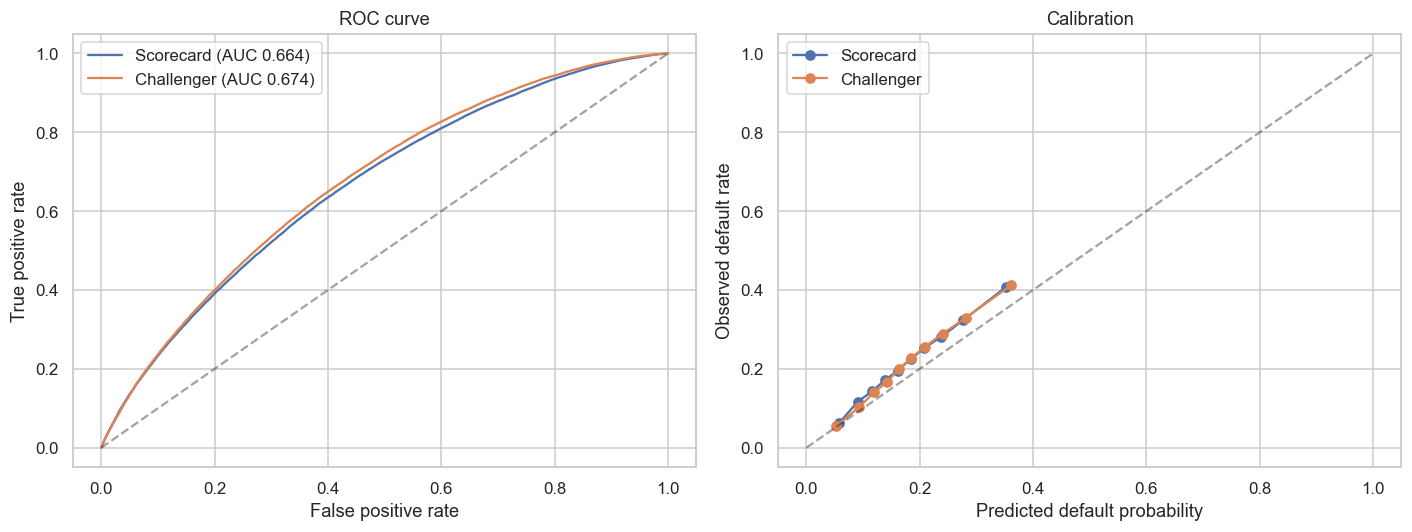

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, proba in [("Scorecard", pd_test_sc), ("Challenger", pd_test_xgb)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC {roc_auc_score(y_test, proba):.3f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set_xlabel("False positive rate"); axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC curve"); axes[0].legend()

for name, proba in [("Scorecard", pd_test_sc), ("Challenger", pd_test_xgb)]:
    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10, strategy="quantile")
    axes[1].plot(mean_pred, frac_pos, "o-", label=name)
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[1].set_xlabel("Predicted default probability"); axes[1].set_ylabel("Observed default rate")
axes[1].set_title("Calibration"); axes[1].legend()

plt.tight_layout(); plt.show()

In [17]:
# Confusion matrix read in lending terms, at an illustrative cutoff.
cutoff = 0.30
predicted_default = (pd_test_sc >= cutoff).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, predicted_default).ravel()
print(f"Scorecard decision at PD >= {cutoff}:")
print(f"  Bad loans approved  (false negatives): {fn:,}  -> direct credit loss")
print(f"  Good customers declined (false positives): {fp:,}  -> forgone revenue")
print(f"  Defaulters correctly declined (recall): {tp / (tp + fn):.2f}")
print(f"  Share of declined that truly default (precision): {tp / (tp + fp):.2f}")

Scorecard decision at PD >= 0.3:
  Bad loans approved  (false negatives): 46,471  -> direct credit loss
  Good customers declined (false positives): 16,075  -> forgone revenue
  Defaulters correctly declined (recall): 0.19
  Share of declined that truly default (precision): 0.41


## 9. Interpretability with SHAP

Interpretability is a requirement in lending, not an optional extra, because a declined applicant is entitled to a reason. SHAP attributes each prediction back to its features, giving both a global view of what drives risk across all applicants and a local view that explains any single decision. This is what makes a non-linear challenger defensible: its behaviour can be shown to agree with credit sense.

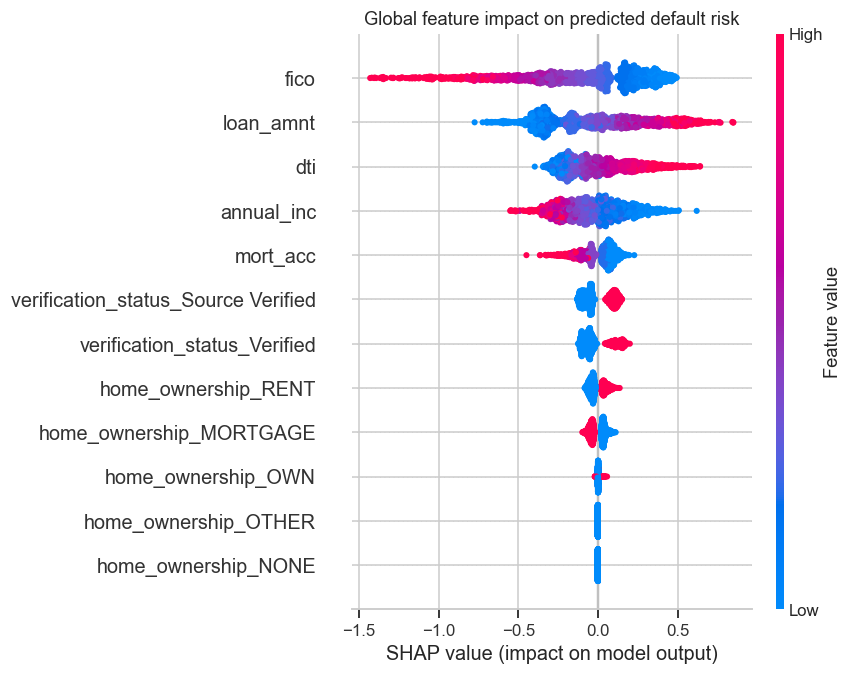

In [18]:
import shap

# Explain a sample for speed; TreeSHAP is exact for tree models.
sample = X_test_raw.sample(min(2000, len(X_test_raw)), random_state=SEED)
explainer = shap.TreeExplainer(xgb)
shap_values = explainer(sample)

shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.title("Global feature impact on predicted default risk")
plt.tight_layout(); plt.show()

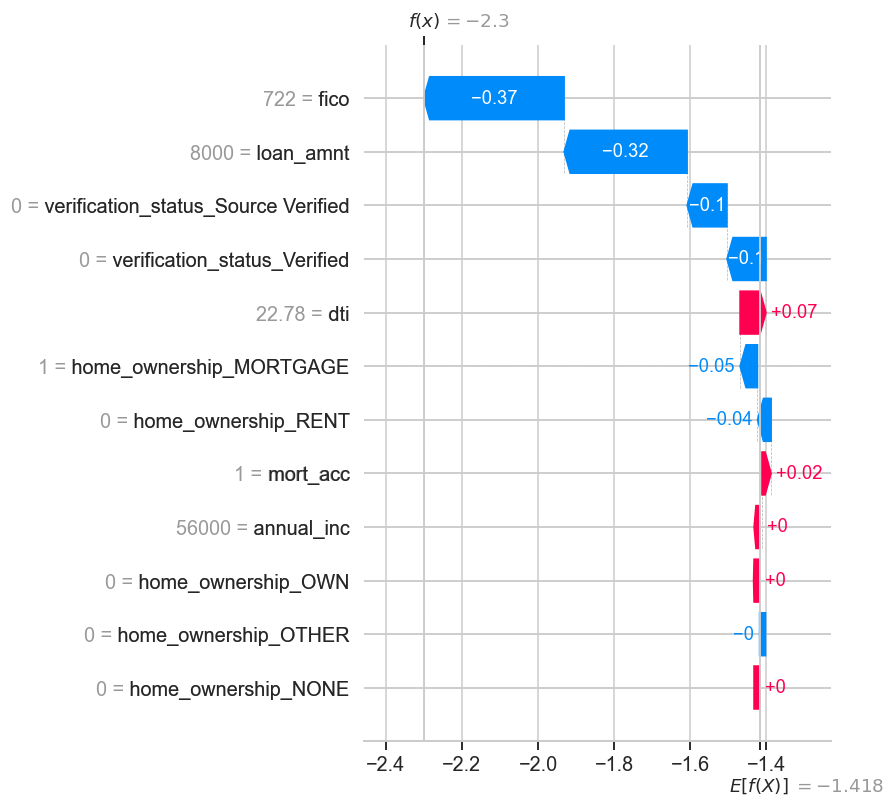

In [19]:
# Local explanation for a single applicant.
shap.plots.waterfall(shap_values[0], max_display=12, show=False)
plt.tight_layout(); plt.show()

## 10. Probability of default to expected loss and a baseline lending cutoff

A probability of default becomes a business input once it is combined with loss severity and exposure. Expected loss is the product of the probability of default, the loss given default, and the exposure at default. Loss given default and exposure are set with stated assumptions here, since the public data does not contain recovery detail; a production model would estimate them directly.

The approve-or-decline cutoff is then chosen by lending economics rather than by a statistical rule. Approving a loan that defaults costs roughly the loss on it; declining a good applicant costs the margin that would have been earned. The cutoff that minimises total expected cost is selected, and its effect is reported in dollars.

Approve or decline is only one lever. Because the model deliberately excludes the lender's own interest rate, the only decision it can express here is to accept or reject. On a population whose default rate sits well above the break even probability implied by these loss assumptions, that forces an unusually conservative cutoff. The next section adds the lever a real lender relies on, which is price.

In [20]:
# Stated assumptions (a production model would estimate LGD and EAD directly).
LGD = 0.55           # loss given default for unsecured consumer credit
MARGIN = 0.05        # net interest margin forgone on a wrongly declined good loan

test = test.copy()
test["pd"] = pd_test_xgb
test["ead"] = test["loan_amnt"]
test["expected_loss"] = test["pd"] * LGD * test["ead"]
print(f"Portfolio expected loss on the test book: ${test['expected_loss'].sum():,.0f}")

thresholds = np.linspace(0.02, 0.60, 60)
records = []
for c in thresholds:
    approve = test["pd"] < c
    bad_approved = approve & (test["default"] == 1)
    good_declined = (~approve) & (test["default"] == 0)
    loss = (LGD * test.loc[bad_approved, "ead"]).sum()
    forgone = (MARGIN * test.loc[good_declined, "ead"]).sum()
    records.append((c, loss + forgone, loss, forgone, int(approve.sum())))

cost = pd.DataFrame(records, columns=["cutoff", "total_cost", "loss", "forgone", "approvals"])
best = cost.loc[cost["total_cost"].idxmin()]
print(f"Cost-minimising cutoff: PD < {best['cutoff']:.3f}")
print(f"  Approvals: {int(best['approvals']):,} of {len(test):,}")
print(f"  Expected loss from approved bad loans: ${best['loss']:,.0f}")
print(f"  Forgone margin from declined good loans: ${best['forgone']:,.0f}")

Portfolio expected loss on the test book: $429,209,478
Cost-minimising cutoff: PD < 0.079
  Approvals: 27,241 of 264,013
  Expected loss from approved bad loans: $9,329,072
  Forgone margin from declined good loans: $130,635,714


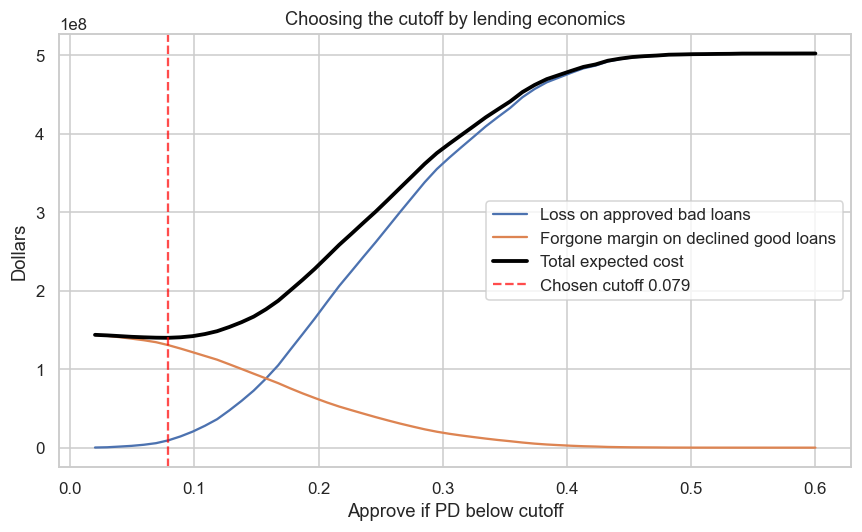

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(cost["cutoff"], cost["loss"], label="Loss on approved bad loans")
ax.plot(cost["cutoff"], cost["forgone"], label="Forgone margin on declined good loans")
ax.plot(cost["cutoff"], cost["total_cost"], label="Total expected cost", linewidth=2.5, color="black")
ax.axvline(best["cutoff"], color="red", linestyle="--", alpha=0.7,
           label=f"Chosen cutoff {best['cutoff']:.3f}")
ax.set_xlabel("Approve if PD below cutoff"); ax.set_ylabel("Dollars")
ax.set_title("Choosing the cutoff by lending economics"); ax.legend()
plt.tight_layout(); plt.show()

## 11. Pricing the risk

A real lender rarely just declines a risky applicant. It prices the risk, charging a higher interest rate so the loan is still expected to be profitable, and declines only when the risk cannot be priced within the rate the lender is able to offer. This section turns each applicant's probability of default into the minimum interest rate that would make the loan meet a target return, approves and prices every applicant that can be priced under a rate cap, and declines the rest. The economics use stated assumptions that a production model would refine.

The section then validates the pricing against an external benchmark. LendingClub's own interest rate was excluded from the entire modelling process, so it never influenced the model. It is loaded here only to compare the model's independently derived prices with what the lender actually charged. Because the price is a direct function of the model's probability of default, this compares whether the model ranks borrower risk the way the lender did, so a rank correlation is the honest measure. Close agreement is evidence that the model's view of risk is sound, even though its headline accuracy is deliberately modest.

In [22]:
# Pricing assumptions (adjustable; a production model would estimate these directly).
FUNDING_COST  = 0.03    # cost of funds per dollar of exposure, annualised
TARGET_RETURN = 0.02    # required expected profit per dollar of exposure, above funding
RATE_CAP      = 0.30    # highest interest rate the lender can offer
# LGD is already defined earlier as 0.55.


def required_rate(pd_hat, lgd=LGD, funding=FUNDING_COST, target=TARGET_RETURN):
    """Minimum interest rate that makes a loan meet the target return, given its default risk.

    One period economics per dollar of exposure:
        expected profit = (1 - PD) * rate  -  PD * LGD  -  funding
    Setting expected profit equal to the target and solving for the rate gives the price
    below. Interest is only collected from borrowers who do not default, which is why the
    rate is divided by (1 - PD): a riskier loan has to charge more to break even.
    """
    pd_hat = np.clip(pd_hat, 0.0, 0.99)          # protect the (1 - PD) denominator
    return (target + funding + pd_hat * lgd) / (1.0 - pd_hat)


test = test.copy()
test["required_rate"] = required_rate(test["pd"].values)
test["priceable"] = test["required_rate"] <= RATE_CAP    # can the risk be priced under the cap?

n_priced = int(test["priceable"].sum())
n_cutoff = int((test["pd"] < best["cutoff"]).sum())
print(f"Pricing approves {n_priced:,} of {len(test):,} ({n_priced / len(test):.1%}) "
      f"within the {RATE_CAP:.0%} rate cap.")
print(f"Baseline cutoff approved {n_cutoff:,} of {len(test):,} ({n_cutoff / len(test):.1%}).")
print(f"Average priced rate: {test.loc[test['priceable'], 'required_rate'].mean():.1%}")


Pricing approves 232,114 of 264,013 (87.9%) within the 30% rate cap.
Baseline cutoff approved 27,241 of 264,013 (10.3%).
Average priced rate: 17.0%


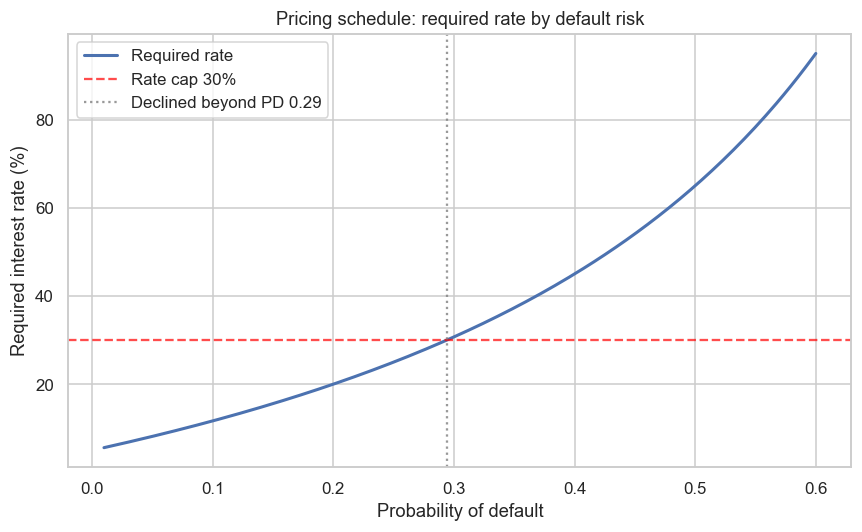

In [23]:
# The pricing schedule: required rate as a function of default risk.
grid = np.linspace(0.01, 0.60, 200)
rate_grid = required_rate(grid)
over_cap = rate_grid > RATE_CAP
pd_at_cap = grid[np.argmax(over_cap)] if over_cap.any() else None

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(grid, rate_grid * 100, color="#4c72b0", linewidth=2, label="Required rate")
ax.axhline(RATE_CAP * 100, color="red", linestyle="--", alpha=0.7, label=f"Rate cap {RATE_CAP:.0%}")
if pd_at_cap is not None:
    ax.axvline(pd_at_cap, color="grey", linestyle=":", alpha=0.8,
               label=f"Declined beyond PD {pd_at_cap:.2f}")
ax.set_xlabel("Probability of default")
ax.set_ylabel("Required interest rate (%)")
ax.set_title("Pricing schedule: required rate by default risk")
ax.legend()
plt.tight_layout(); plt.show()


In [24]:
# Expected profit under pricing versus the baseline approve or decline cutoff.
# Priced strategy: each approved loan is charged its required rate, so by construction it
# earns the target return per dollar of exposure in expectation.
priced_profit = (TARGET_RETURN * test.loc[test["priceable"], "ead"]).sum()

# Baseline strategy: approve or decline only; good loans earn the flat margin, bad loans
# lose LGD of exposure.
approve_base = test["pd"] < best["cutoff"]
good_base = approve_base & (test["default"] == 0)
bad_base = approve_base & (test["default"] == 1)
base_profit = (MARGIN * test.loc[good_base, "ead"]).sum() - (LGD * test.loc[bad_base, "ead"]).sum()

print("Expected portfolio profit on the test book:")
print(f"  Baseline approve or decline : ${base_profit:,.0f}")
print(f"  Pricing the risk            : ${priced_profit:,.0f}")
print("Pricing serves far more exposure at a positive expected margin instead of declining")
print("the whole risky tail. This assumes offered rates are accepted, with no take up or")
print("adverse selection modelling, which a production model would add.")


Expected portfolio profit on the test book:
  Baseline approve or decline : $4,160,334
  Pricing the risk            : $62,313,715
Pricing serves far more exposure at a positive expected margin instead of declining
the whole risky tail. This assumes offered rates are accepted, with no take up or
adverse selection modelling, which a production model would add.


Model price vs actual LendingClub rate: Spearman 0.497, Pearson 0.455
The prices were built with no knowledge of the lender's rates, so this agreement is
independent evidence that the model's ranking of borrower risk is sensible.


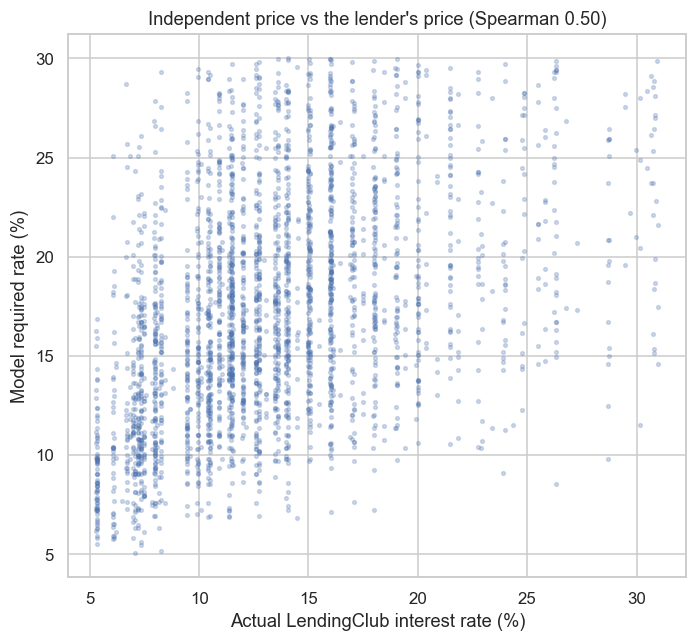

In [25]:
# External validation. int_rate was never used in training. It is loaded here only to
# benchmark the model's prices against the lender's actual pricing. The row index has been
# preserved throughout the pipeline, so selecting test.index aligns the actual rates to the
# test loans.
actual = (pd.read_csv(ACCEPTED_DATA_PATH, usecols=["int_rate"])
            .loc[test.index, "int_rate"]
            .astype(str).str.rstrip("%").replace({"nan": np.nan}).astype(float))
test["actual_rate"] = actual.values

valid = test["actual_rate"].notna() & test["priceable"]
rho = test.loc[valid, "required_rate"].corr(test.loc[valid, "actual_rate"], method="spearman")
r_lin = test.loc[valid, "required_rate"].corr(test.loc[valid, "actual_rate"] / 100.0, method="pearson")
print(f"Model price vs actual LendingClub rate: Spearman {rho:.3f}, Pearson {r_lin:.3f}")
print("The prices were built with no knowledge of the lender's rates, so this agreement is")
print("independent evidence that the model's ranking of borrower risk is sensible.")

samp = test.loc[valid].sample(min(3000, int(valid.sum())), random_state=SEED)
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(samp["actual_rate"], samp["required_rate"] * 100, s=6, alpha=0.25, color="#4c72b0")
ax.set_xlabel("Actual LendingClub interest rate (%)")
ax.set_ylabel("Model required rate (%)")
ax.set_title(f"Independent price vs the lender's price (Spearman {rho:.2f})")
plt.tight_layout(); plt.show()


## 12. Fairness and adverse-impact review

Lending decisions are tested for disparate impact, where a neutral rule produces unequal outcomes across groups. This dataset does not contain protected attributes such as race or gender, so a true fair lending test is not possible. What is shown instead is a proxy review across income bands, which are available, and it looks at both levers the model now has.

The first lever is who gets approved. Under the baseline cutoff, approvals concentrate heavily among higher earners, because income is correlated with default. Pricing the risk improves this, since lower income applicants are priced rather than declined outright. The second lever is the rate itself. Pricing can move the disparity from approval into the rate that is charged, and charging higher rates to groups that correlate with protected classes is itself a fair lending concern. Both are reported below. As before, income is a proxy and not a protected attribute, so a full assessment would require attributes the public data does not hold.

In [26]:
test["income_band"] = pd.qcut(test["annual_inc"], 4, labels=["Q1", "Q2", "Q3", "Q4"])

# Lever one: who gets approved, under the baseline cutoff versus pricing.
appr_cutoff = (test["pd"] < best["cutoff"]).groupby(test["income_band"], observed=False).mean()
appr_priced = test["priceable"].groupby(test["income_band"], observed=False).mean()
air_cutoff = appr_cutoff.min() / appr_cutoff.max()
air_priced = appr_priced.min() / appr_priced.max()

# Lever two: the rate charged to those who are approved under pricing.
rate_by_income = (test.loc[test["priceable"]]
                  .groupby("income_band", observed=False)["required_rate"].mean())

print("Approval rate by income band (proxy segment):")
print(pd.DataFrame({"cutoff_only": appr_cutoff.round(3),
                    "priced": appr_priced.round(3)}).to_string())
print(f"\nAdverse-impact ratio (min / max approval rate):")
print(f"  Cutoff only : {air_cutoff:.3f}")
print(f"  Pricing     : {air_priced:.3f}")
print("Reference: below 0.80 would warrant scrutiny under the four-fifths rule.")
print("\nAverage offered rate by income band (pricing-side check):")
print((rate_by_income * 100).round(1).to_string())
print("\nPricing raises approval parity by pricing lower income applicants rather than")
print("declining them, but it can shift the disparity into the rate offered, which is")
print("itself a fair lending consideration. Income is a proxy, not a protected attribute;")
print("a full fair-lending review would require attributes not present in this dataset.")


Approval rate by income band (proxy segment):
             cutoff_only  priced
income_band                     
Q1                 0.030   0.824
Q2                 0.081   0.853
Q3                 0.124   0.895
Q4                 0.179   0.945

Adverse-impact ratio (min / max approval rate):
  Cutoff only : 0.169
  Pricing     : 0.872
Reference: below 0.80 would warrant scrutiny under the four-fifths rule.

Average offered rate by income band (pricing-side check):
income_band
Q1    19.0
Q2    17.4
Q3    16.5
Q4    15.4

Pricing raises approval parity by pricing lower income applicants rather than
declining them, but it can shift the disparity into the rate offered, which is
itself a fair lending consideration. Income is a proxy, not a protected attribute;
a full fair-lending review would require attributes not present in this dataset.


## 13. Model-risk summary and limitations

**Purpose.** An application-time probability of default model for consumer loans, delivered as an interpretable scorecard with a gradient boosting challenger, and used to estimate expected loss, set a price that reflects each borrower's risk, and support a lending decision.

**Data and target.** LendingClub public loan book. The target is a binary default flag defined from resolved outcomes, with fully paid loans as goods and charged-off or defaulted loans as bads. Unresolved loans are excluded.

**Key design controls.** Only application-time features are loaded, which prevents post-outcome leakage. LendingClub's own grade, sub-grade, interest rate, and installment are excluded so the model is independent of the lender's existing decision. The train and test split is time-based, and all learned transformations are fit on training data only.

**Assumptions.** Loss given default and exposure at default are set with stated assumptions rather than modelled, because the public data lacks recovery detail. The cutoff and the pricing use an assumed cost of funds, target return, and net interest margin.

**Performance.** Reported on a time-based holdout using AUC, Gini, KS, and calibration. Ranking power is reported honestly, and the challenger's accuracy gain over the interpretable scorecard is modest, which is the expected trade-off and the reason a scorecard remains the sensible deployment choice. The ranking is also validated externally against LendingClub's own interest rates, which the model never used, and the two agree closely.

**Limitations.** The model is trained only on accepted loans, which are a non random sample of all applicants, so it can be miscalibrated on the true through the door population. The standard remedy is reject inference, which is not attempted here because the public rejected applications file has no recorded outcome to infer from, so the limitation is stated instead. Beyond that, the data is a single lender's population that may not generalise, there are no protected attributes for a full fairness assessment, loss and exposure are assumed rather than modelled, the pricing assumes offered rates are accepted, and the data covers a fixed historical window rather than a full economic cycle.

**Monitoring.** In production this model would be monitored for population drift using the population stability index, checked periodically for calibration against realised default rates, and recalibrated or redeveloped when either drifts materially.